In [27]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

In [28]:
# Load data set
df = pd.read_csv("diabetes_dataset.csv")

In [29]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [30]:
# check missing values
print(df.isna())

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin    BMI  \
0          False    False          False          False    False  False   
1          False    False          False          False    False  False   
2          False    False          False          False    False  False   
3          False    False          False          False    False  False   
4          False    False          False          False    False  False   
..           ...      ...            ...            ...      ...    ...   
763        False    False          False          False    False  False   
764        False    False          False          False    False  False   
765        False    False          False          False    False  False   
766        False    False          False          False    False  False   
767        False    False          False          False    False  False   

     DiabetesPedigreeFunction    Age  Outcome  
0                       False  False    False  
1  

In [31]:
print(df.isna().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [32]:
df[df.isna().any(axis=1)]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


In [33]:
# check duplicate rows
df.duplicated()[df.duplicated()==True]

Series([], dtype: bool)

In [34]:
# No. rows and cols
print(df.shape)

(768, 9)


In [35]:
# check data types
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [36]:
df['Insulin'] =df['Insulin'].astype(float)

In [37]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [38]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [39]:
df.describe(include="all")

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


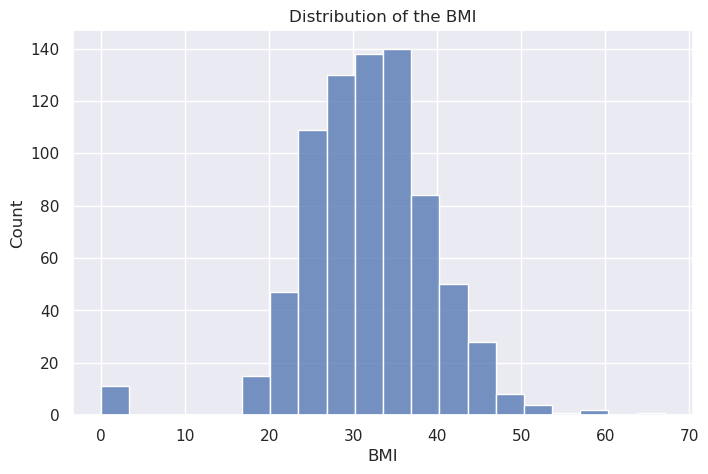

In [40]:
plt.figure(figsize=(8,5))
sns.histplot(df["BMI"], bins= 20)

plt.title("Distribution of the BMI")
plt.show()

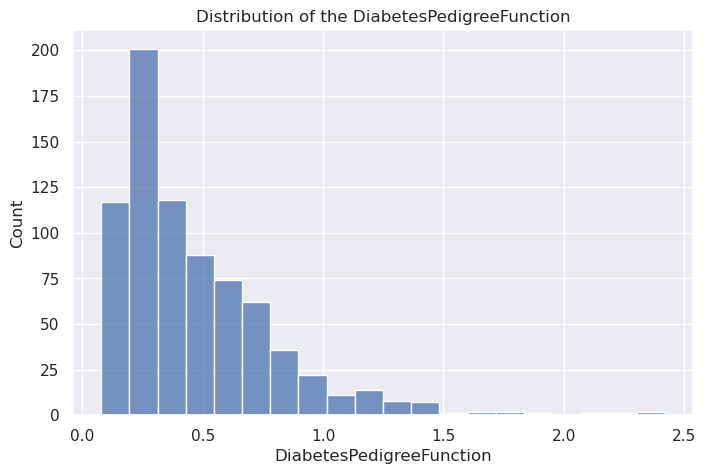

In [41]:
plt.figure(figsize=(8,5))
sns.histplot(df["DiabetesPedigreeFunction"], bins= 20)
plt.title("Distribution of the DiabetesPedigreeFunction")
plt.show()

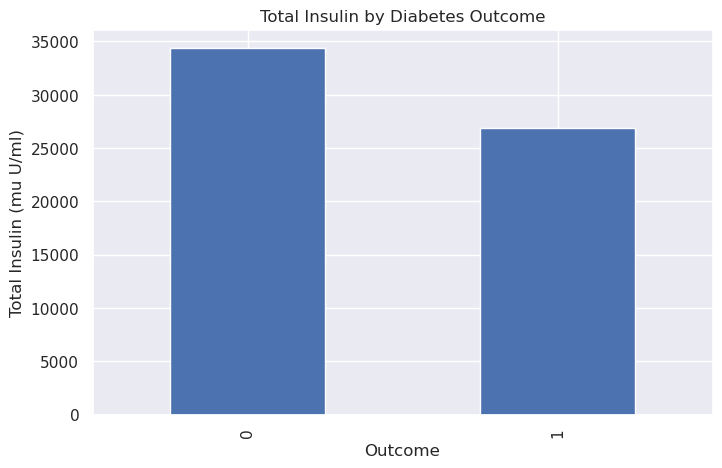

Outcome
0    34396.0
1    26890.0
Name: Insulin, dtype: float64

In [42]:
outcome_insulin = df.groupby("Outcome")["Insulin"].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
outcome_insulin.plot(kind ="bar")
plt.title("Total Insulin by Diabetes Outcome")
plt.ylabel("Total Insulin (mu U/ml)")
plt.show()

outcome_insulin

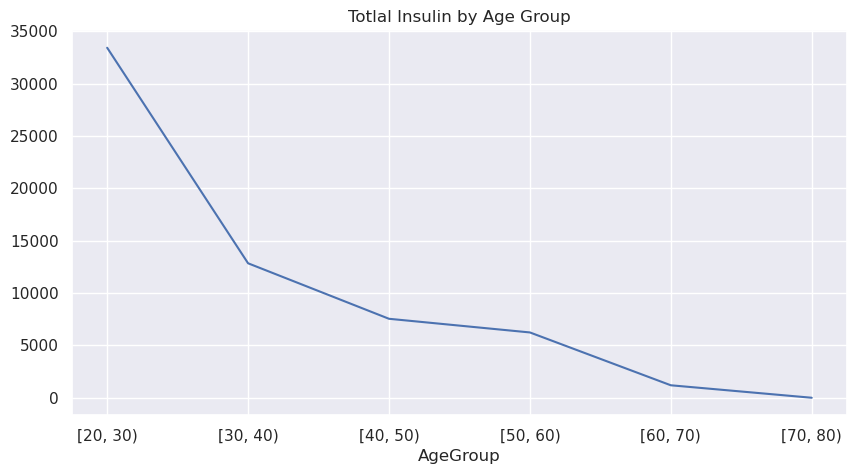

In [43]:
age_bins = [20,30,40,50,60,70,80]
df["AgeGroup"] = pd.cut(df["Age"], bins=age_bins, right=False)
age_insulin = df.groupby('AgeGroup')['Insulin'].sum()

plt.figure(figsize=(10,5))
age_insulin.plot()
plt.title("Totlal Insulin by Age Group")
plt.show()

In [44]:
df.head(50)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,AgeGroup
0,6,148,72,35,0.0,33.6,0.627,50,1,"[50, 60)"
1,1,85,66,29,0.0,26.6,0.351,31,0,"[30, 40)"
2,8,183,64,0,0.0,23.3,0.672,32,1,"[30, 40)"
3,1,89,66,23,94.0,28.1,0.167,21,0,"[20, 30)"
4,0,137,40,35,168.0,43.1,2.288,33,1,"[30, 40)"
5,5,116,74,0,0.0,25.6,0.201,30,0,"[30, 40)"
6,3,78,50,32,88.0,31.0,0.248,26,1,"[20, 30)"
7,10,115,0,0,0.0,35.3,0.134,29,0,"[20, 30)"
8,2,197,70,45,543.0,30.5,0.158,53,1,"[50, 60)"
9,8,125,96,0,0.0,0.0,0.232,54,1,"[50, 60)"
